In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', subdir, f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [4]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'Hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'Ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [5]:
hydrogenBAUDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production without electricity, steam reforming') & ~hydrogenGWPDF['Activity'].str.contains('CCS')]
hydrogenBaseBAUDF = hydrogenBAUDF[hydrogenBAUDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenBAUDF.merge(hydrogenBaseBAUDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
hydrogenMergedDF['Percentage difference'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP_base']) / hydrogenMergedDF['GWP_base']) * 100
hydrogenMergedDFImage = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('image') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDFRemind = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('remind') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenGroupedBAUDFImage = hydrogenMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedBAUDFImage = hydrogenGroupedBAUDFImage.reset_index()
hydrogenGroupedBAUDFRemind = hydrogenMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedBAUDFRemind = hydrogenGroupedBAUDFRemind.reset_index()

hydrogenSolarDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('solar')]
hydrogenBaseSolarDF = hydrogenSolarDF[hydrogenSolarDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenSolarDF.merge(hydrogenBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
hydrogenMergedDF['Percentage difference'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP_base']) / hydrogenMergedDF['GWP_base']) * 100
hydrogenMergedDFImage = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('image') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDFRemind = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('remind') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenGroupedSolarDFImage = hydrogenMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedSolarDFImage = hydrogenGroupedSolarDFImage.reset_index()
hydrogenGroupedSolarDFRemind = hydrogenMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedSolarDFRemind = hydrogenGroupedSolarDFRemind.reset_index()

hydrogenWindDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('onshore wind')]
hydrogenBaseWindDF = hydrogenWindDF[hydrogenWindDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenWindDF.merge(hydrogenBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
hydrogenMergedDF['Percentage difference'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP_base']) / hydrogenMergedDF['GWP_base']) * 100
hydrogenMergedDFImage = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('image') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDFRemind = hydrogenMergedDF[hydrogenMergedDF['Database'].str.contains('remind') & ~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenGroupedWindDFImage = hydrogenMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedWindDFImage = hydrogenGroupedWindDFImage.reset_index()
hydrogenGroupedWindDFRemind = hydrogenMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
hydrogenGroupedWindDFRemind = hydrogenGroupedWindDFRemind.reset_index()

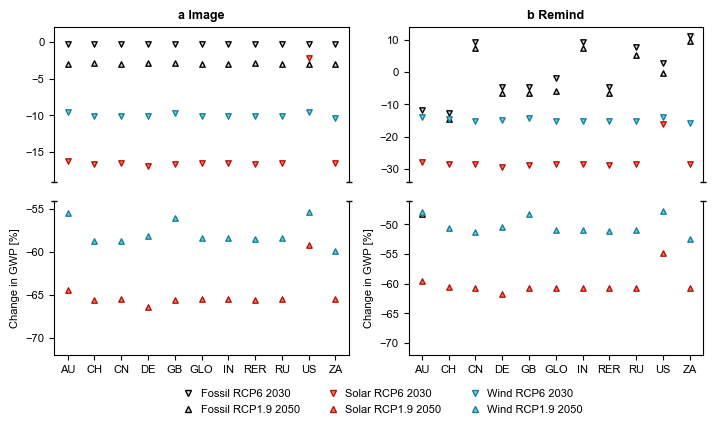

In [6]:
fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, sharex = True, figsize = (fig_length[2], fig_height*0.4), gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace = 0) 

ax1.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax1.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax1.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.set_ylim([-19, 2])
ax1.set_title('a Image', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax2.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(hydrogenGroupedBAUDFImage['Location'], hydrogenGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax2.scatter(hydrogenGroupedSolarDFImage['Location'], hydrogenGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax2.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.scatter(hydrogenGroupedWindDFImage['Location'], hydrogenGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.set_ylim([-72, -54])

ax3.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax3.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax3.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.set_ylim([-34, 14])
ax3.set_title('b Remind', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax4.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(hydrogenGroupedBAUDFRemind['Location'], hydrogenGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax4.scatter(hydrogenGroupedSolarDFRemind['Location'], hydrogenGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax4.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.scatter(hydrogenGroupedWindDFRemind['Location'], hydrogenGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.set_ylim([-72, -46])

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

ax2.set_ylabel(r'Change in GWP [%]')

ax4.set_ylabel(r'Change in GWP [%]')

legend_elements = [Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP6 2030', markersize = 4),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP1.9 2050', markersize = 4),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP6 2030', markersize = 4),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP1.9 2050', markersize = 4),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP6 2030', markersize = 4),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP1.9 2050', markersize = 4),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Hydrogen WO Elec SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Hydrogen WO Elec SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight')

In [7]:
ammoniaBAUDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('ammonia, BAU')]
ammoniaBaseBAUDF = ammoniaBAUDF[ammoniaBAUDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaBAUDF.merge(ammoniaBaseBAUDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
ammoniaMergedDF['Percentage difference'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP_base']) / ammoniaMergedDF['GWP_base']) * 100
ammoniaMergedDFImage = ammoniaMergedDF[ammoniaMergedDF['Database'].str.contains('image') & ~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDFRemind = ammoniaMergedDF[ammoniaMergedDF['Database'].str.contains('remind') & ~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaGroupedBAUDFImage = ammoniaMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ammoniaGroupedBAUDFImage = ammoniaGroupedBAUDFImage.reset_index()
ammoniaGroupedBAUDFRemind = ammoniaMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ammoniaGroupedBAUDFRemind = ammoniaGroupedBAUDFRemind.reset_index()

ammoniaSolarDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('solar')]
ammoniaBaseSolarDF = ammoniaSolarDF[ammoniaSolarDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaSolarDF.merge(ammoniaBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
ammoniaMergedDF['Percentage difference'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP_base']) / ammoniaMergedDF['GWP_base']) * 100
ammoniaMergedDFImage = ammoniaMergedDF[ammoniaMergedDF['Database'].str.contains('image') & ~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDFRemind = ammoniaMergedDF[ammoniaMergedDF['Database'].str.contains('remind') & ~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaGroupedSolarDFImage = ammoniaMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ammoniaGroupedSolarDFImage = ammoniaGroupedSolarDFImage.reset_index()
ammoniaGroupedSolarDFRemind = ammoniaMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ammoniaGroupedSolarDFRemind = ammoniaGroupedSolarDFRemind.reset_index()

ammoniaWindDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('onshore wind')]
ammoniaBaseWindDF = ammoniaWindDF[ammoniaWindDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaWindDF.merge(ammoniaBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
ammoniaMergedDF['Percentage difference'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP_base']) / ammoniaMergedDF['GWP_base']) * 100
ammoniaMergedDFImage = ammoniaMergedDF[ammoniaMergedDF['Database'].str.contains('image') & ~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDFRemind = ammoniaMergedDF[ammoniaMergedDF['Database'].str.contains('remind') & ~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaGroupedWindDFImage = ammoniaMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ammoniaGroupedWindDFImage = ammoniaGroupedWindDFImage.reset_index()
ammoniaGroupedWindDFRemind = ammoniaMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ammoniaGroupedWindDFRemind = ammoniaGroupedWindDFRemind.reset_index()

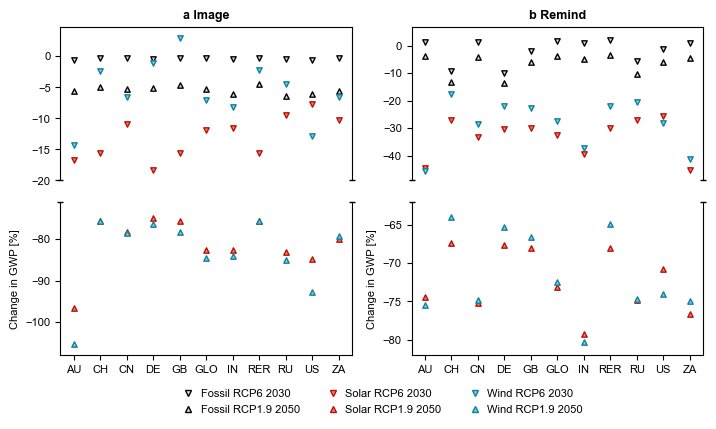

In [8]:
fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, sharex = True, figsize = (fig_length[2], fig_height*0.4), gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace = 0) 

ax1.scatter(ammoniaGroupedBAUDFImage['Location'], ammoniaGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(ammoniaGroupedBAUDFImage['Location'], ammoniaGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(ammoniaGroupedSolarDFImage['Location'], ammoniaGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax1.scatter(ammoniaGroupedSolarDFImage['Location'], ammoniaGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax1.scatter(ammoniaGroupedWindDFImage['Location'], ammoniaGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.scatter(ammoniaGroupedWindDFImage['Location'], ammoniaGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.set_ylim([-20, 4.7])
ax1.set_title('a Image', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax2.scatter(ammoniaGroupedBAUDFImage['Location'], ammoniaGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(ammoniaGroupedBAUDFImage['Location'], ammoniaGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(ammoniaGroupedSolarDFImage['Location'], ammoniaGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax2.scatter(ammoniaGroupedSolarDFImage['Location'], ammoniaGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax2.scatter(ammoniaGroupedWindDFImage['Location'], ammoniaGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.scatter(ammoniaGroupedWindDFImage['Location'], ammoniaGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.set_ylim([-108, -71])

ax3.scatter(ammoniaGroupedBAUDFRemind['Location'], ammoniaGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(ammoniaGroupedBAUDFRemind['Location'], ammoniaGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(ammoniaGroupedSolarDFRemind['Location'], ammoniaGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax3.scatter(ammoniaGroupedSolarDFRemind['Location'], ammoniaGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax3.scatter(ammoniaGroupedWindDFRemind['Location'], ammoniaGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.scatter(ammoniaGroupedWindDFRemind['Location'], ammoniaGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.set_ylim([-49, 6.7])
ax3.set_title('b Remind', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax4.scatter(ammoniaGroupedBAUDFRemind['Location'], ammoniaGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(ammoniaGroupedBAUDFRemind['Location'], ammoniaGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(ammoniaGroupedSolarDFRemind['Location'], ammoniaGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax4.scatter(ammoniaGroupedSolarDFRemind['Location'], ammoniaGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax4.scatter(ammoniaGroupedWindDFRemind['Location'], ammoniaGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.scatter(ammoniaGroupedWindDFRemind['Location'], ammoniaGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.set_ylim([-82, -62])

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

ax2.set_ylabel(r'Change in GWP [%]')

ax4.set_ylabel(r'Change in GWP [%]')

legend_elements = [Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP6 2030', markersize = 4),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP1.9 2050', markersize = 4),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP6 2030', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP1.9 2050', markersize = 5),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP6 2030', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP1.9 2050', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Ammonia SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Ammonia SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight')

In [9]:
methanolBAUDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol, BAU')]
methanolBaseBAUDF = methanolBAUDF[methanolBAUDF['Database'].str.contains('2020')]
methanolMergedDF = methanolBAUDF.merge(methanolBaseBAUDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
methanolMergedDF['Percentage difference'] = ((methanolMergedDF['GWP'] - methanolMergedDF['GWP_base']) / methanolMergedDF['GWP_base']) * 100
methanolMergedDFImage = methanolMergedDF[methanolMergedDF['Database'].str.contains('image') & ~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDFRemind = methanolMergedDF[methanolMergedDF['Database'].str.contains('remind') & ~methanolMergedDF['Database'].str.contains('2020')]
methanolGroupedBAUDFImage = methanolMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
methanolGroupedBAUDFImage = methanolGroupedBAUDFImage.reset_index()
methanolGroupedBAUDFRemind = methanolMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
methanolGroupedBAUDFRemind = methanolGroupedBAUDFRemind.reset_index()

methanolSolarDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolBaseSolarDF = methanolSolarDF[methanolSolarDF['Database'].str.contains('2020')]
methanolMergedDF = methanolSolarDF.merge(methanolBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
methanolMergedDF['Percentage difference'] = -((methanolMergedDF['GWP'] - methanolMergedDF['GWP_base']) / methanolMergedDF['GWP_base']) * 100
methanolMergedDFImage = methanolMergedDF[methanolMergedDF['Database'].str.contains('image') & ~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDFRemind = methanolMergedDF[methanolMergedDF['Database'].str.contains('remind') & ~methanolMergedDF['Database'].str.contains('2020')]
methanolGroupedSolarDFImage = methanolMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
methanolGroupedSolarDFImage = methanolGroupedSolarDFImage.reset_index()
methanolGroupedSolarDFRemind = methanolMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
methanolGroupedSolarDFRemind = methanolGroupedSolarDFRemind.reset_index()

methanolWindDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolBaseWindDF = methanolWindDF[methanolWindDF['Database'].str.contains('2020')]
methanolMergedDF = methanolWindDF.merge(methanolBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
methanolMergedDF['Percentage difference'] = -((methanolMergedDF['GWP'] - methanolMergedDF['GWP_base']) / methanolMergedDF['GWP_base']) * 100
methanolMergedDFImage = methanolMergedDF[methanolMergedDF['Database'].str.contains('image') & ~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDFRemind = methanolMergedDF[methanolMergedDF['Database'].str.contains('remind') & ~methanolMergedDF['Database'].str.contains('2020')]
methanolGroupedWindDFImage = methanolMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
methanolGroupedWindDFImage = methanolGroupedWindDFImage.reset_index()
methanolGroupedWindDFRemind = methanolMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
methanolGroupedWindDFRemind = methanolGroupedWindDFRemind.reset_index()

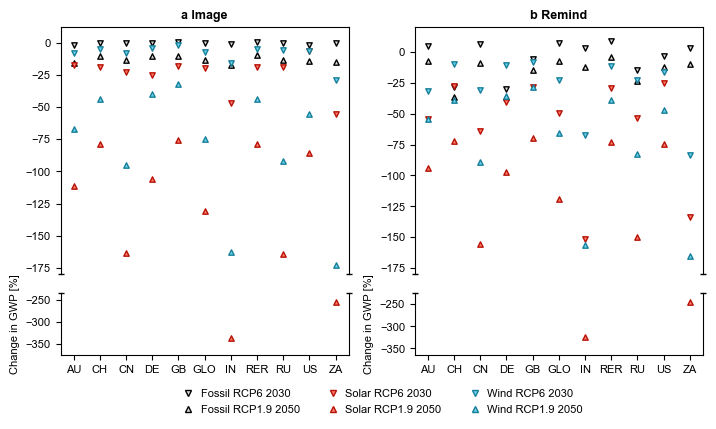

In [10]:
fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, sharex = True, figsize = (fig_length[2], fig_height*0.4), gridspec_kw={'height_ratios': [4, 1]})
fig.subplots_adjust(hspace = 0) 

ax1.scatter(methanolGroupedBAUDFImage['Location'], methanolGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(methanolGroupedBAUDFImage['Location'], methanolGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(methanolGroupedSolarDFImage['Location'], methanolGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax1.scatter(methanolGroupedSolarDFImage['Location'], methanolGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax1.scatter(methanolGroupedWindDFImage['Location'], methanolGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.scatter(methanolGroupedWindDFImage['Location'], methanolGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.set_ylim([-180, 12])
ax1.set_title('a Image', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax2.scatter(methanolGroupedBAUDFImage['Location'], methanolGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(methanolGroupedBAUDFImage['Location'], methanolGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(methanolGroupedSolarDFImage['Location'], methanolGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax2.scatter(methanolGroupedSolarDFImage['Location'], methanolGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax2.scatter(methanolGroupedWindDFImage['Location'], methanolGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.scatter(methanolGroupedWindDFImage['Location'], methanolGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.set_ylim([-375, -235])

ax3.scatter(methanolGroupedBAUDFRemind['Location'], methanolGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(methanolGroupedBAUDFRemind['Location'], methanolGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(methanolGroupedSolarDFRemind['Location'], methanolGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax3.scatter(methanolGroupedSolarDFRemind['Location'], methanolGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax3.scatter(methanolGroupedWindDFRemind['Location'], methanolGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.scatter(methanolGroupedWindDFRemind['Location'], methanolGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.set_ylim([-180, 20])
ax3.set_title('b Remind', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax4.scatter(methanolGroupedBAUDFRemind['Location'], methanolGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(methanolGroupedBAUDFRemind['Location'], methanolGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(methanolGroupedSolarDFRemind['Location'], methanolGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax4.scatter(methanolGroupedSolarDFRemind['Location'], methanolGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax4.scatter(methanolGroupedWindDFRemind['Location'], methanolGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.scatter(methanolGroupedWindDFRemind['Location'], methanolGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.set_ylim([-365, -225])

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

ax2.set_ylabel(r'Change in GWP [%]')

ax4.set_ylabel(r'Change in GWP [%]')

legend_elements = [Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP6 2030', markersize = 4),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP1.9 2050', markersize = 4),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP6 2030', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP1.9 2050', markersize = 5),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP6 2030', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP1.9 2050', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Methanol SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Methanol SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight')

In [11]:
ethyleneBAUDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
ethyleneBaseBAUDF = ethyleneBAUDF[ethyleneBAUDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneBAUDF.merge(ethyleneBaseBAUDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
ethyleneMergedDF['Percentage difference'] = ((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP_base']) / ethyleneMergedDF['GWP_base']) * 100
ethyleneMergedDFImage = ethyleneMergedDF[ethyleneMergedDF['Database'].str.contains('image') & ~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDFRemind = ethyleneMergedDF[ethyleneMergedDF['Database'].str.contains('remind') & ~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneGroupedBAUDFImage = ethyleneMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ethyleneGroupedBAUDFImage = ethyleneGroupedBAUDFImage.reset_index()
ethyleneGroupedBAUDFRemind = ethyleneMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ethyleneGroupedBAUDFRemind = ethyleneGroupedBAUDFRemind.reset_index()

ethyleneSolarDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneBaseSolarDF = ethyleneSolarDF[ethyleneSolarDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneSolarDF.merge(ethyleneBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
ethyleneMergedDF['Percentage difference'] = -((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP_base']) / ethyleneMergedDF['GWP_base']) * 100
ethyleneMergedDFImage = ethyleneMergedDF[ethyleneMergedDF['Database'].str.contains('image') & ~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDFRemind = ethyleneMergedDF[ethyleneMergedDF['Database'].str.contains('remind') & ~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneGroupedSolarDFImage = ethyleneMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ethyleneGroupedSolarDFImage = ethyleneGroupedSolarDFImage.reset_index()
ethyleneGroupedSolarDFRemind = ethyleneMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ethyleneGroupedSolarDFRemind = ethyleneGroupedSolarDFRemind.reset_index()

ethyleneWindDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneBaseWindDF = ethyleneWindDF[ethyleneWindDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneWindDF.merge(ethyleneBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', '_base'))
ethyleneMergedDF['Percentage difference'] = -((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP_base']) / ethyleneMergedDF['GWP_base']) * 100
ethyleneMergedDFImage = ethyleneMergedDF[ethyleneMergedDF['Database'].str.contains('image') & ~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDFRemind = ethyleneMergedDF[ethyleneMergedDF['Database'].str.contains('remind') & ~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneGroupedWindDFImage = ethyleneMergedDFImage.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ethyleneGroupedWindDFImage = ethyleneGroupedWindDFImage.reset_index()
ethyleneGroupedWindDFRemind = ethyleneMergedDFRemind.groupby('Location')['Percentage difference'].agg(['min', 'max'])
ethyleneGroupedWindDFRemind = ethyleneGroupedWindDFRemind.reset_index()

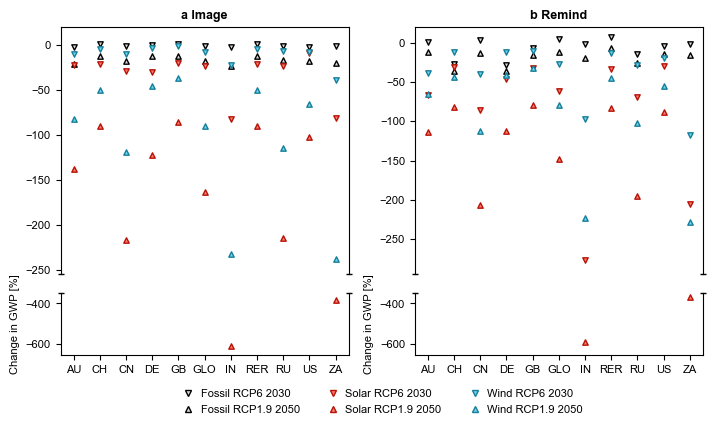

In [12]:
fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, sharex = True, figsize = (fig_length[2], fig_height*0.4), gridspec_kw={'height_ratios': [4, 1]})
fig.subplots_adjust(hspace = 0) 

ax1.scatter(ethyleneGroupedBAUDFImage['Location'], ethyleneGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(ethyleneGroupedBAUDFImage['Location'], ethyleneGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax1.scatter(ethyleneGroupedSolarDFImage['Location'], ethyleneGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax1.scatter(ethyleneGroupedSolarDFImage['Location'], ethyleneGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax1.scatter(ethyleneGroupedWindDFImage['Location'], ethyleneGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.scatter(ethyleneGroupedWindDFImage['Location'], ethyleneGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax1.set_ylim([-255, 20])
ax1.set_title('a Image', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax2.scatter(ethyleneGroupedBAUDFImage['Location'], ethyleneGroupedBAUDFImage['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(ethyleneGroupedBAUDFImage['Location'], ethyleneGroupedBAUDFImage['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax2.scatter(ethyleneGroupedSolarDFImage['Location'], ethyleneGroupedSolarDFImage['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax2.scatter(ethyleneGroupedSolarDFImage['Location'], ethyleneGroupedSolarDFImage['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax2.scatter(ethyleneGroupedWindDFImage['Location'], ethyleneGroupedWindDFImage['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.scatter(ethyleneGroupedWindDFImage['Location'], ethyleneGroupedWindDFImage['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax2.set_ylim([-655, -350])

ax3.scatter(ethyleneGroupedBAUDFRemind['Location'], ethyleneGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(ethyleneGroupedBAUDFRemind['Location'], ethyleneGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax3.scatter(ethyleneGroupedSolarDFRemind['Location'], ethyleneGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax3.scatter(ethyleneGroupedSolarDFRemind['Location'], ethyleneGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax3.scatter(ethyleneGroupedWindDFRemind['Location'], ethyleneGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.scatter(ethyleneGroupedWindDFRemind['Location'], ethyleneGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax3.set_ylim([-295, 20])
ax3.set_title('b Remind', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

ax4.scatter(ethyleneGroupedBAUDFRemind['Location'], ethyleneGroupedBAUDFRemind['min'], marker = '^', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(ethyleneGroupedBAUDFRemind['Location'], ethyleneGroupedBAUDFRemind['max'], marker = 'v', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1, s = 15)
ax4.scatter(ethyleneGroupedSolarDFRemind['Location'], ethyleneGroupedSolarDFRemind['min'], marker = '^', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 2, s = 15)
ax4.scatter(ethyleneGroupedSolarDFRemind['Location'], ethyleneGroupedSolarDFRemind['max'], marker = 'v', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 3, s = 15)
ax4.scatter(ethyleneGroupedWindDFRemind['Location'], ethyleneGroupedWindDFRemind['min'], marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.scatter(ethyleneGroupedWindDFRemind['Location'], ethyleneGroupedWindDFRemind['max'], marker = 'v', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 3, s = 15)
ax4.set_ylim([-655, -350])

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

ax2.set_ylabel(r'Change in GWP [%]')

ax4.set_ylabel(r'Change in GWP [%]')

legend_elements = [Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP6 2030', markersize = 4),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil RCP1.9 2050', markersize = 4),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP6 2030', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar RCP1.9 2050', markersize = 5),
                   Line2D([0], [0], marker = 'v', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP6 2030', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind RCP1.9 2050', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Ethylene SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Percent GWP Regional', 'Ethylene SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight')